Available sheets: ['Sheet2', 'Sheet5', 'Sheet6', 'Sheet7', 'Sheet8', 'Sheet9', 'Sheet11', 'Sheet12', 'Sheet13', 'Sheet14', 'Sheet15', 'Sheet16', 'Sheet17', 'Sheet18', 'Sheet19', 'Sheet20', 'Sheet21', 'Sheet23', 'Sheet24', 'Sheet25', 'Sheet26', 'Sheet27', 'Sheet28', 'Sheet29', 'Sheet30', 'Sheet32', 'Sheet33', 'Sheet34', 'Sheet35', 'Sheet36', 'Sheet37', 'Sheet39', 'Sheet40', 'Sheet41', 'Sheet42', 'Sheet43', 'Sheet44', 'Sheet45', 'Sheet46', 'Sheet48', 'Sheet50', 'Sheet51', 'Sheet52', 'Sheet53', 'Sheet54', 'Sheet55', 'Sheet56', 'Sheet57', 'Sheet58', 'Sheet59', 'Sheet60', 'Sheet62', 'Sheet63', 'Sheet65', 'Sheet66', 'Sheet67', 'Sheet68', 'Sheet69', 'Sheet70', 'Sheet73', 'Sheet74', 'Sheet75', 'Sheet76', 'Sheet77', 'Sheet78', 'Sheet80', 'Sheet81', 'Sheet84', 'Sheet86', 'Sheet87', 'Sheet89', 'Sheet90', 'Sheet92', 'Sheet93', 'Sheet94', 'Sheet95', 'Sheet96', 'Sheet97', 'Sheet98', 'Sheet99', 'Sheet100', 'Sheet101', 'Sheet102', 'Sheet103', 'Sheet107', 'Sheet108', 'Sheet110', 'Sheet111', 'Sheet112',

<ipython-input-1-94cd1fce1c3d>:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


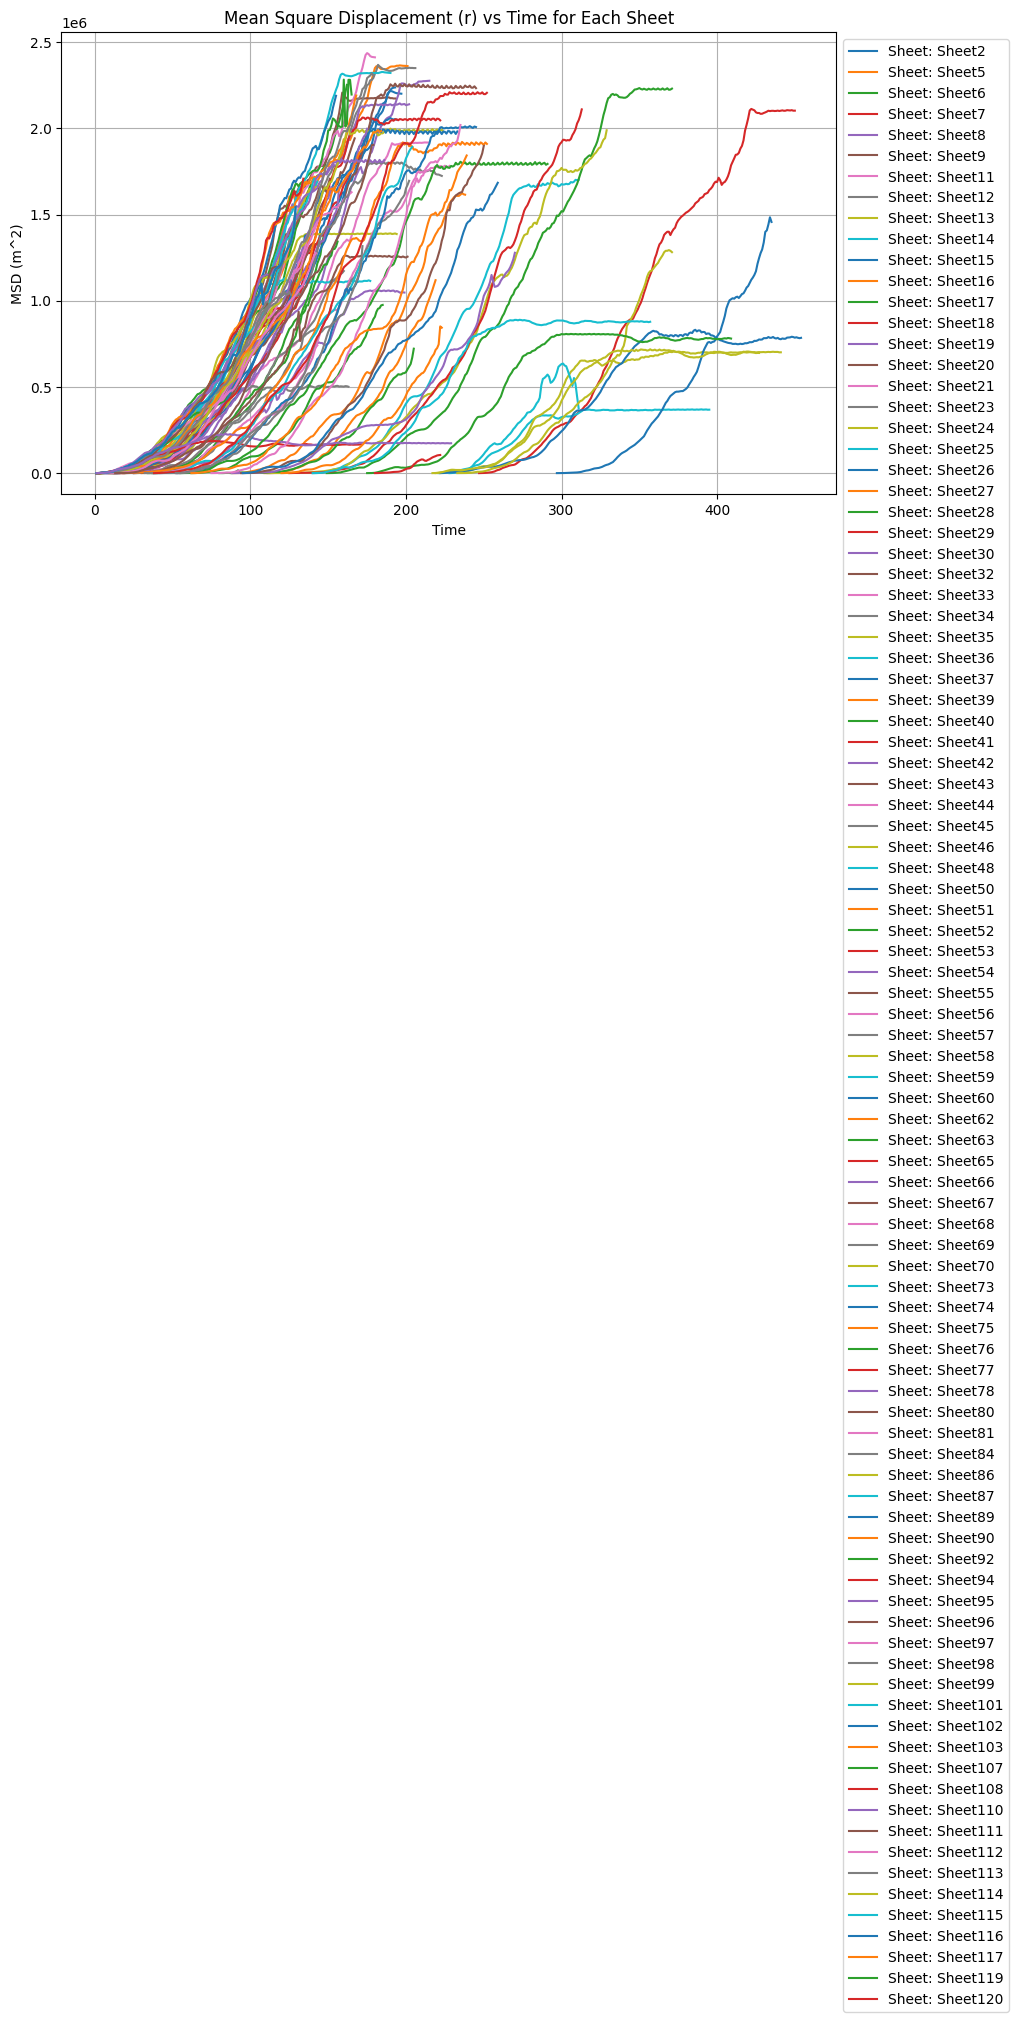

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants for pixel-to-meter conversion
x_pixel_to_meter = 1  # / 1080
y_pixel_to_meter = 1  # / 1920

# Function to read data from Excel sheets and calculate MSD for each sheet
def calculate_and_plot_msd(file_path):
    # Load the Excel file and get sheet names
    xls = pd.ExcelFile(file_path)
    print("Available sheets:", xls.sheet_names)

    plt.figure(figsize=(10, 6))  # Increase figure size for better clarity

    for sheet in xls.sheet_names:
        print(f"Processing sheet: {sheet}")

        # Read data from each sheet
        df = pd.read_excel(file_path, sheet_name=sheet)
        print(df.head())  # Display the first few rows for debugging

        # Ensure required columns exist
        if df.shape[1] >= 8:
            # Extract X, Y, and time columns (X: col 5, Y: col 6, Time: col 8)
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7]

            print(f"x_data length: {len(x_data)}, y_data length: {len(y_data)}, time_data length: {len(time_data)}")

            # Check if data is not empty
            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                print(f"Empty data in sheet: {sheet}")
                continue

            # Calculate displacement 'r' (distance from the initial position)
            r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2

            # Ensure lengths of time and r_squared match
            if len(time_data) == len(r_squared):
                # Plot MSD vs Time for the current sheet
                plt.plot(time_data, r_squared, label=f'Sheet: {sheet}')
            else:
                print(f"Length mismatch in sheet {sheet}: time({len(time_data)}) vs r_squared({len(r_squared)})")

        else:
            print(f"Skipping sheet '{sheet}' as it doesn't contain required columns")

    # Finalize the plot
    plt.title('Mean Square Displacement (r) vs Time for Each Sheet')
    plt.xlabel('Time')
    plt.ylabel('MSD (m^2)')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

# File path to the Excel file
file_path = '/content/empty_core­_raw­_data.xlsx'  # Replace with your actual file path

# Run the function
calculate_and_plot_msd(file_path)


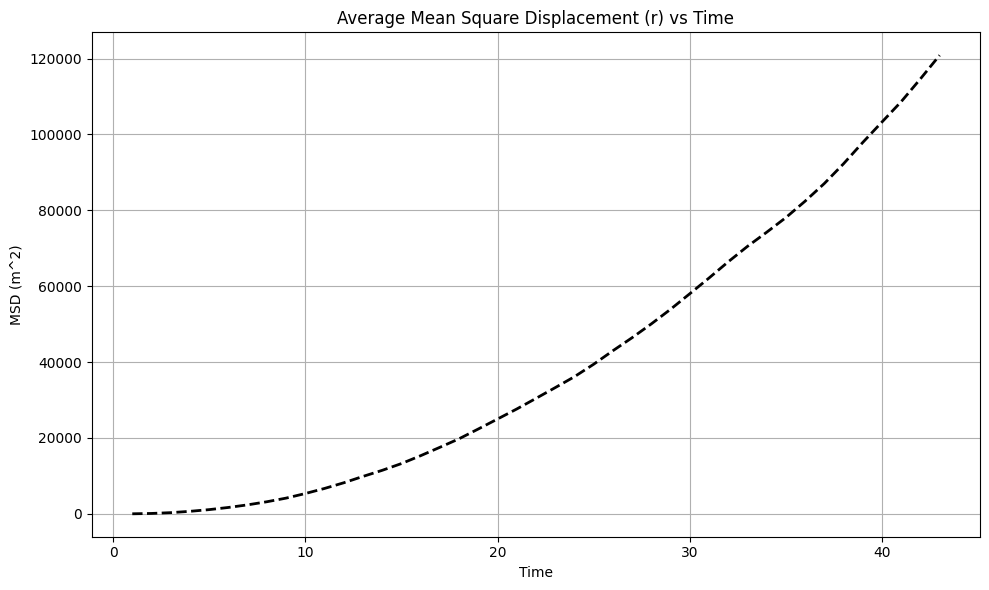

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants for pixel-to-meter conversion
x_pixel_to_meter = 1  # / 1080
y_pixel_to_meter = 1  # / 1920

# Function to read data from Excel sheets and calculate the average MSD
def calculate_and_plot_average_msd(file_path):
    # Load the Excel file and get sheet names
    xls = pd.ExcelFile(file_path)

    all_r_squared = []
    all_time_data = []

    for sheet in xls.sheet_names:
        # Read data from each sheet
        df = pd.read_excel(file_path, sheet_name=sheet)

        # Ensure required columns exist
        if df.shape[1] >= 8:
            # Extract X, Y, and time columns (X: col 5, Y: col 6, Time: col 8)
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7]

            # Check if data is not empty
            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                continue

            # Calculate displacement 'r' (distance from the initial position)
            r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2

            # Ensure lengths of time and r_squared match
            if len(time_data) == len(r_squared):
                # Store r_squared and time data for averaging later
                all_r_squared.append(r_squared.values)
                all_time_data.append(time_data.values)

    # Calculate the average MSD across all sheets
    if all_r_squared:
        min_length = min(map(len, all_r_squared))
        avg_r_squared = np.mean([r[:min_length] for r in all_r_squared], axis=0)
        avg_time = all_time_data[0][:min_length]

        # Plot the average MSD
        plt.figure(figsize=(10, 6))
        plt.plot(avg_time, avg_r_squared, 'k--', linewidth=2)

        # Finalize the plot
        plt.title('Average Mean Square Displacement (r) vs Time')
        plt.xlabel('Time')
        plt.ylabel('MSD (m^2)')
        plt.grid(True)
        plt.tight_layout()
        plt.show(block=True)

# File path to the Excel file
file_path = '/content/empty_core­_raw­_data.xlsx'  # Replace with your actual file path

# Run the function
calculate_and_plot_average_msd(file_path)


In [ ]:
#FOR ALL TRACKS(NORMALIZED)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants for pixel-to-meter conversion
x_pixel_to_meter = 1  # / 1080
y_pixel_to_meter = 1  # / 1920

# Function to read data from Excel sheets and calculate the average MSD
def calculate_and_plot_average_msd(file_path):
    # Load the Excel file and get sheet names
    xls = pd.ExcelFile(file_path)

    all_r_squared = []
    all_time_data = []

    for sheet in xls.sheet_names:
        # Read data from each sheet
        df = pd.read_excel(file_path, sheet_name=sheet)

        # Ensure required columns exist
        if df.shape[1] >= 8:
            # Extract X, Y, and time columns (X: col 5, Y: col 6, Time: col 8)
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7]

            # Check if data is not empty
            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                continue

            # Calculate displacement 'r' (distance from the initial position)
            r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2

            # Store r_squared and time data for averaging later
            all_r_squared.append(r_squared.values)
            all_time_data.append(time_data.values)

    # Normalize all time and MSD data to the longest length
    if all_r_squared:
        max_length = max(map(len, all_r_squared))

        # Interpolate all data to match the maximum length
        interpolated_r_squared = [np.interp(np.linspace(0, 1, max_length), np.linspace(0, 1, len(r)), r) for r in all_r_squared]
        avg_r_squared = np.mean(interpolated_r_squared, axis=0)

        # Use the maximum length time axis
        avg_time = np.linspace(0, max([t.max() for t in all_time_data]), max_length)

        # Plot the average MSD
        #plt.figure(figsize=(10, 6))
        #plt.plot(avg_time, avg_r_squared, 'k--', linewidth=2)

        print(avg_time,' '   ,avg_r_squared, '\n')

        # Finalize the plot
        #plt.title('Average Mean Square Displacement (r) vs Time')
        #plt.xlabel('Time')
        #plt.ylabel('MSD (m^2)')
        #plt.grid(True)
        #plt.tight_layout()
        #plt.show(block=True)

# File path to the Excel file
file_path = '/content/1by8_inch_steel_ball_raw_data.xlsx'  # Replace with your actual file path

# Run the function
calculate_and_plot_average_msd(file_path)




[  0.           1.18644068   2.37288136   3.55932203   4.74576271
   5.93220339   7.11864407   8.30508475   9.49152542  10.6779661
  11.86440678  13.05084746  14.23728814  15.42372881  16.61016949
  17.79661017  18.98305085  20.16949153  21.3559322   22.54237288
  23.72881356  24.91525424  26.10169492  27.28813559  28.47457627
  29.66101695  30.84745763  32.03389831  33.22033898  34.40677966
  35.59322034  36.77966102  37.96610169  39.15254237  40.33898305
  41.52542373  42.71186441  43.89830508  45.08474576  46.27118644
  47.45762712  48.6440678   49.83050847  51.01694915  52.20338983
  53.38983051  54.57627119  55.76271186  56.94915254  58.13559322
  59.3220339   60.50847458  61.69491525  62.88135593  64.06779661
  65.25423729  66.44067797  67.62711864  68.81355932  70.
  71.18644068  72.37288136  73.55932203  74.74576271  75.93220339
  77.11864407  78.30508475  79.49152542  80.6779661   81.86440678
  83.05084746  84.23728814  85.42372881  86.61016949  87.79661017
  88.98305085  90.1

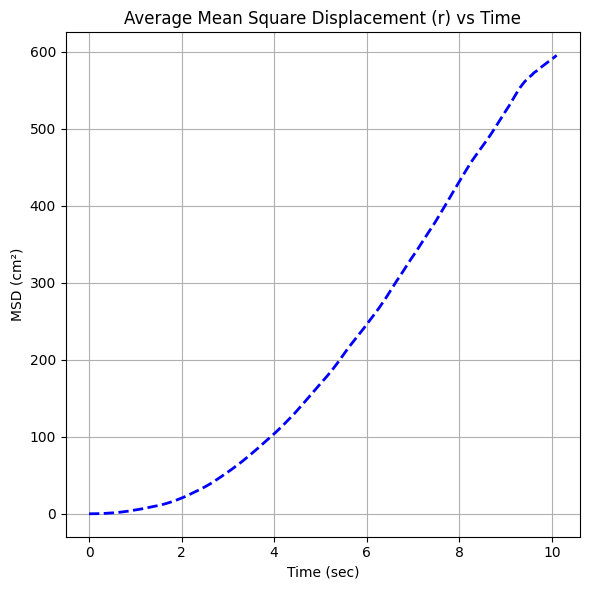

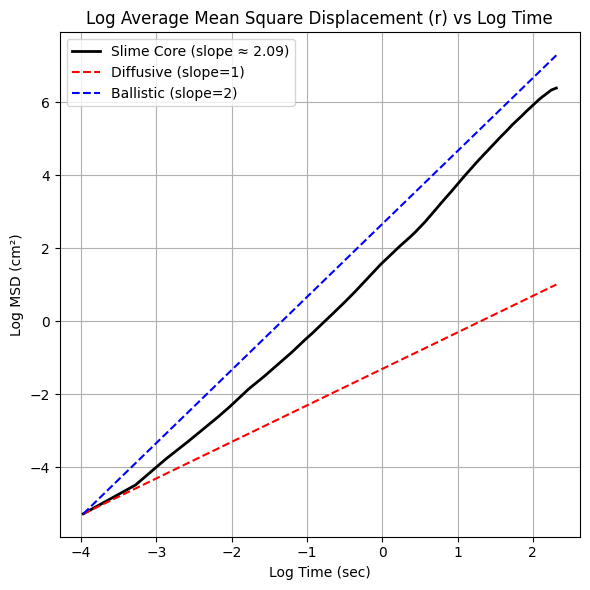

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Constants for pixel-to-meter conversion
x_pixel_to_meter = 0.01899
y_pixel_to_meter = 0.01911
t_frame_to_sec = 0.01667

# Function to read data from Excel sheets and calculate the average MSD
def calculate_and_plot_average_msd(file_path):
    # Load the Excel file and get sheet names
    xls = pd.ExcelFile(file_path)

    all_r_squared = []
    all_time_data = []

    for sheet in xls.sheet_names:
        # Read data from each sheet
        df = pd.read_excel(file_path, sheet_name=sheet)

        # Ensure required columns exist
        if df.shape[1] >= 8:
            # Extract X, Y, and time columns (X: col 5, Y: col 6, Time: col 8)
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7] * t_frame_to_sec

            # Check if data is not empty
            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                continue

            # Calculate displacement 'r' (distance from the initial position)
            r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2

            # Store r_squared and time data for averaging later
            all_r_squared.append(r_squared.values)
            all_time_data.append(time_data.values)

    # Normalize all time and MSD data to the longest length
    if all_r_squared:
        max_length = max(map(len, all_r_squared))

        # Interpolate all data to match the maximum length
        interpolated_r_squared = [np.interp(np.linspace(0, 1, max_length), np.linspace(0, 1, len(r)), r) for r in all_r_squared]
        avg_r_squared = np.mean(interpolated_r_squared, axis=0)

        # Use the maximum length time axis
        avg_time = np.linspace(0, max([t.max() for t in all_time_data]), max_length)

        # Filter valid positive values for log-log plotting
        valid = (avg_time > 0) & (avg_r_squared > 0)
        logt  = np.log(avg_time[valid])
        logr2 = np.log(avg_r_squared[valid])

        # Compute slope using linear regression in log-log space
        slope, intercept, r_value, p_value, std_err = linregress(logt, logr2)

        # Plot the average MSD (linear scale)
        plt.figure(figsize=(6, 6))
        plt.plot(avg_time, avg_r_squared, 'b--', linewidth=2)
        plt.title('Average Mean Square Displacement (r) vs Time')
        plt.xlabel('Time (sec)')
        plt.ylabel('MSD (cm²)')
        plt.grid(True)
        plt.tight_layout()
        plt.show(block=True)

        # Plot the log-log MSD with slope 1 and 2 reference lines
        plt.figure(figsize=(6, 6))
        plt.plot(logt, logr2, 'k-', linewidth=2, label=f'Slime Core (slope ≈ {slope:.2f})')

        # Reference lines for slope 1 and 2
        x_ref = np.linspace(logt.min(), logt.max(), 100)
        y_diffusive = x_ref * 1 + (logr2[0] - logt[0] * 1)  # slope 1
        y_ballistic = x_ref * 2 + (logr2[0] - logt[0] * 2)  # slope 2

        plt.plot(x_ref, y_diffusive, 'r--', label='Diffusive (slope=1)')
        plt.plot(x_ref, y_ballistic, 'b--', label='Ballistic (slope=2)')

        plt.title('Log Average Mean Square Displacement (r) vs Log Time')
        plt.xlabel('Log Time (sec)')
        plt.ylabel('Log MSD (cm²)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show(block=True)

# File path to the Excel file
file_path = '/content/slime_core.xlsx'  # Replace with actual file path

# Run the function
calculate_and_plot_average_msd(file_path)


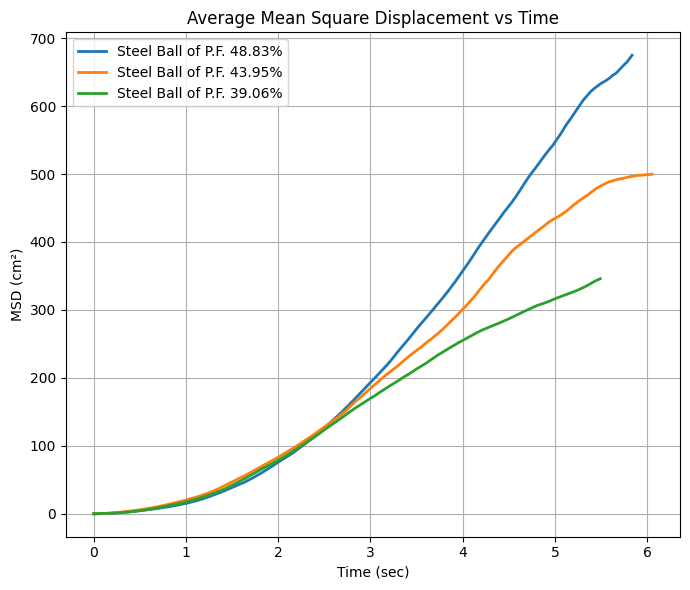

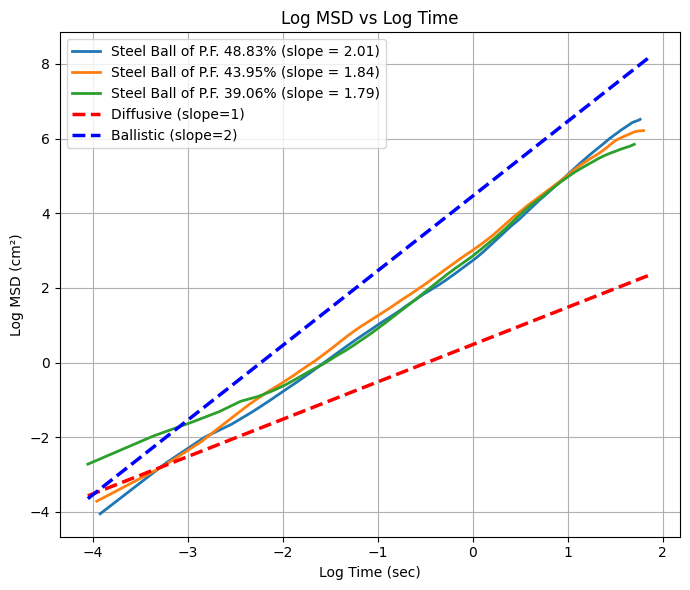

In [ ]:
#STEEL BALLS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Conversion constants
x_pixel_to_meter = 0.01899
y_pixel_to_meter = 0.01911
t_frame_to_sec = 0.01667

# List of file paths and corresponding labels
file_paths = [
    '/content/1by8_inch_steel_ball_raw_data.xlsx',
    '/content/steel_ball_n_225_raw_data.xlsx',
    '/content/steel_ball_n_200_raw_data.xlsx'
]

labels = [
    'Steel Ball of P.F. 48.83%',
    'Steel Ball of P.F. 43.95%',
    'Steel Ball of P.F. 39.06%'
]

# Store average time and MSD for each file
all_avg_time = []
all_avg_msd = []
slopes = []
first_log_points = []

# Process each file
for file_path in file_paths:
    xls = pd.ExcelFile(file_path)

    all_r_squared = []
    all_time_data = []

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)

        if df.shape[1] >= 8:
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7] * t_frame_to_sec

            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                continue

            r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2
            all_r_squared.append(r_squared.values)
            all_time_data.append(time_data.values)

    if all_r_squared:
        max_length = max(map(len, all_r_squared))

        interpolated_r_squared = [
            np.interp(np.linspace(0, 1, max_length), np.linspace(0, 1, len(r)), r)
            for r in all_r_squared
        ]
        avg_r_squared = np.mean(interpolated_r_squared, axis=0)
        avg_time = np.linspace(0, max([t.max() for t in all_time_data]), max_length)

        all_avg_time.append(avg_time)
        all_avg_msd.append(avg_r_squared)

        # Calculate slope in log-log space
        valid = (avg_time > 0) & (avg_r_squared > 0)
        log_time = np.log(avg_time[valid])
        log_msd = np.log(avg_r_squared[valid])

        finite_mask = np.isfinite(log_time) & np.isfinite(log_msd)
        log_time = log_time[finite_mask]
        log_msd = log_msd[finite_mask]

        if len(log_time) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(log_time, log_msd)
            slopes.append(slope)
            first_log_points.append((log_time[0], log_msd[0]))  # For reference lines
        else:
            slopes.append(np.nan)
            first_log_points.append((np.nan, np.nan))


# Plot MSD vs Time (linear scale)
plt.figure(figsize=(7, 6))
for time, msd, label in zip(all_avg_time, all_avg_msd, labels):
    plt.plot(time, msd, linewidth=2, label=label)

plt.title('Average Mean Square Displacement vs Time')
plt.xlabel('Time (sec)')
plt.ylabel('MSD (cm²)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Log(MSD) vs Log(Time) with slopes and one set of reference lines from average starting point
plt.figure(figsize=(7, 6))

# Plot each MSD curve with its slope
for time, msd, label, slope in zip(all_avg_time, all_avg_msd, labels, slopes):
    log_time = np.log(time[time > 0])
    log_msd = np.log(msd[time > 0])
    plt.plot(log_time, log_msd, linewidth=2, label=f'{label} (slope = {slope:.2f})')

# Compute average of valid starting points
valid_points = [(x0, y0) for x0, y0 in first_log_points if not np.isnan(x0) and not np.isnan(y0)]
if valid_points:
    x0_avg = np.mean([pt[0] for pt in valid_points])
    y0_avg = np.mean([pt[1] for pt in valid_points])

    x_ref = np.linspace(min(log_time), max(log_time), 100)
    y_diffusive = x_ref * 1 + (y0_avg - x0_avg * 1)
    y_ballistic = x_ref * 2 + (y0_avg - x0_avg * 2)

    plt.plot(x_ref, y_diffusive, 'r--', linewidth=2.5, label='Diffusive (slope=1)')
    plt.plot(x_ref, y_ballistic, 'b--', linewidth=2.5, label='Ballistic (slope=2)')

plt.title('Log MSD vs Log Time')
plt.xlabel('Log Time (sec)')
plt.ylabel('Log MSD (cm²)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



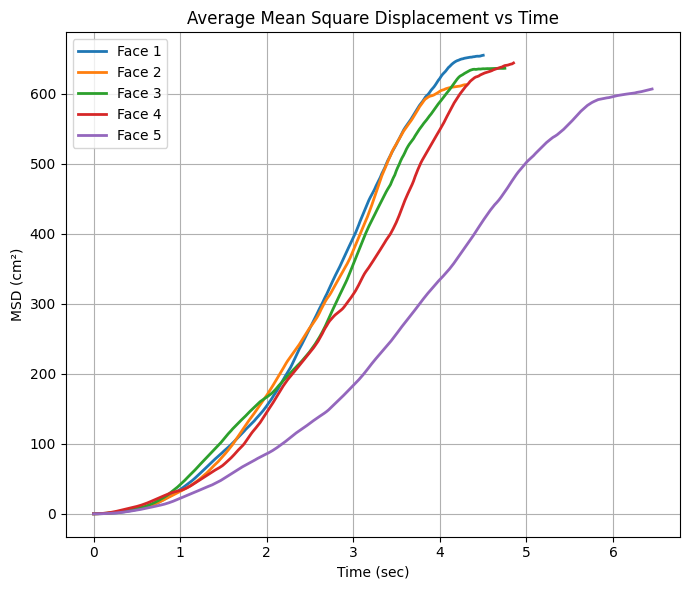

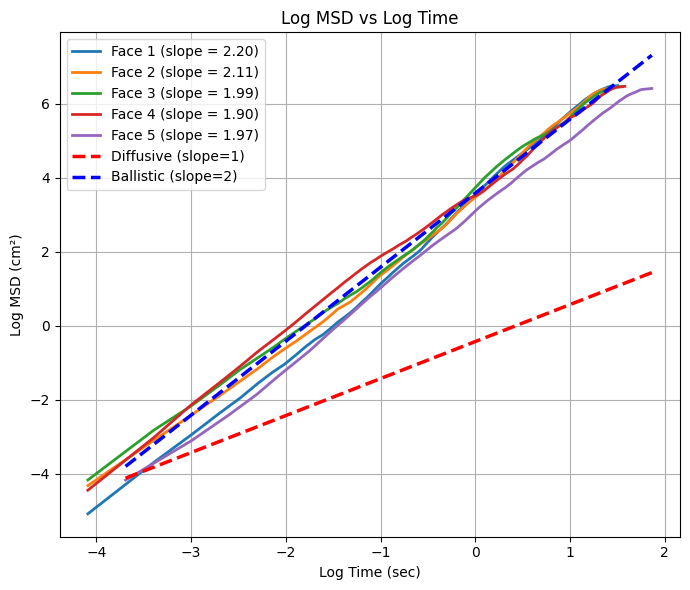

In [ ]:
#FACES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Conversion constants
x_pixel_to_meter = 0.01899
y_pixel_to_meter = 0.01911
t_frame_to_sec = 0.01667

# List of file paths and corresponding labels
file_paths = [
    '/content/face_ch_1.xlsx',
    '/content/face_ch_2.xlsx',
    '/content/face_ch_3.xlsx',
    '/content/face_ch_4.xlsx',
    '/content/face_ch_5.xlsx'
]

labels = [
    'Face 1',
    'Face 2',
    'Face 3',
    'Face 4',
    'Face 5'
]

# Store average time and MSD for each file
all_avg_time = []
all_avg_msd = []
slopes = []
first_log_points = []

# Process each file
for file_path in file_paths:
    xls = pd.ExcelFile(file_path)

    all_r_squared = []
    all_time_data = []

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)

        if df.shape[1] >= 8:
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7] * t_frame_to_sec

            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                continue

            r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2
            all_r_squared.append(r_squared.values)
            all_time_data.append(time_data.values)

    if all_r_squared:
        max_length = max(map(len, all_r_squared))

        interpolated_r_squared = [
            np.interp(np.linspace(0, 1, max_length), np.linspace(0, 1, len(r)), r)
            for r in all_r_squared
        ]
        avg_r_squared = np.mean(interpolated_r_squared, axis=0)
        avg_time = np.linspace(0, max([t.max() for t in all_time_data]), max_length)

        all_avg_time.append(avg_time)
        all_avg_msd.append(avg_r_squared)

        # Calculate slope in log-log space
        valid = (avg_time > 0) & (avg_r_squared > 0)
        log_time = np.log(avg_time[valid])
        log_msd = np.log(avg_r_squared[valid])

        finite_mask = np.isfinite(log_time) & np.isfinite(log_msd)
        log_time = log_time[finite_mask]
        log_msd = log_msd[finite_mask]

        if len(log_time) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(log_time, log_msd)
            slopes.append(slope)
            first_log_points.append((log_time[0], log_msd[0]))  # For reference lines
        else:
            slopes.append(np.nan)
            first_log_points.append((np.nan, np.nan))


# Plot MSD vs Time (linear scale)
plt.figure(figsize=(7, 6))
for time, msd, label in zip(all_avg_time, all_avg_msd, labels):
    plt.plot(time, msd, linewidth=2, label=label)

plt.title('Average Mean Square Displacement vs Time')
plt.xlabel('Time (sec)')
plt.ylabel('MSD (cm²)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Log(MSD) vs Log(Time) with slopes and one set of reference lines from average starting point
plt.figure(figsize=(7, 6))

# Plot each MSD curve with its slope
for time, msd, label, slope in zip(all_avg_time, all_avg_msd, labels, slopes):
    log_time = np.log(time[time > 0])
    log_msd = np.log(msd[time > 0])
    plt.plot(log_time, log_msd, linewidth=2, label=f'{label} (slope = {slope:.2f})')

# Compute average of valid starting points
valid_points = [(x0, y0) for x0, y0 in first_log_points if not np.isnan(x0) and not np.isnan(y0)]
if valid_points:
    x0_avg = np.mean([pt[0] for pt in valid_points])
    y0_avg = np.mean([pt[1] for pt in valid_points])

    x_ref = np.linspace(min(log_time), max(log_time), 100)
    y_diffusive = x_ref * 1 + (y0_avg - x0_avg * 1)
    y_ballistic = x_ref * 2 + (y0_avg - x0_avg * 2)

    plt.plot(x_ref, y_diffusive, 'r--', linewidth=2.5, label='Diffusive (slope=1)')
    plt.plot(x_ref, y_ballistic, 'b--', linewidth=2.5, label='Ballistic (slope=2)')

plt.title('Log MSD vs Log Time')
plt.xlabel('Log Time (sec)')
plt.ylabel('Log MSD (cm²)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



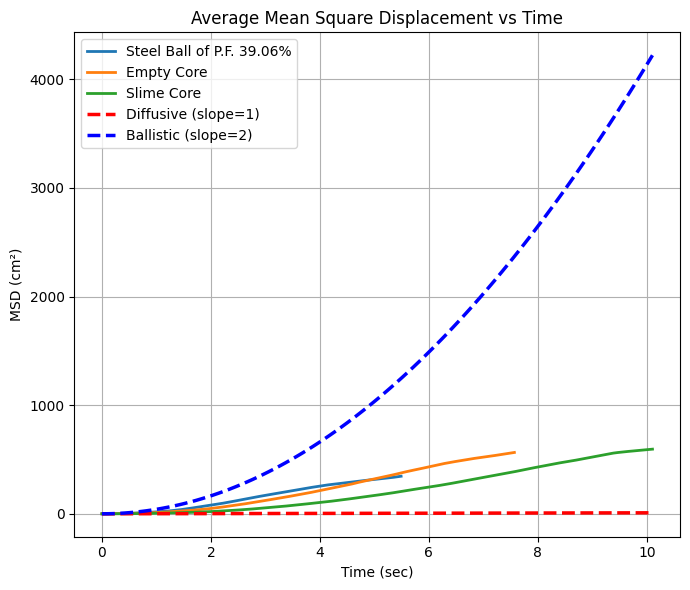

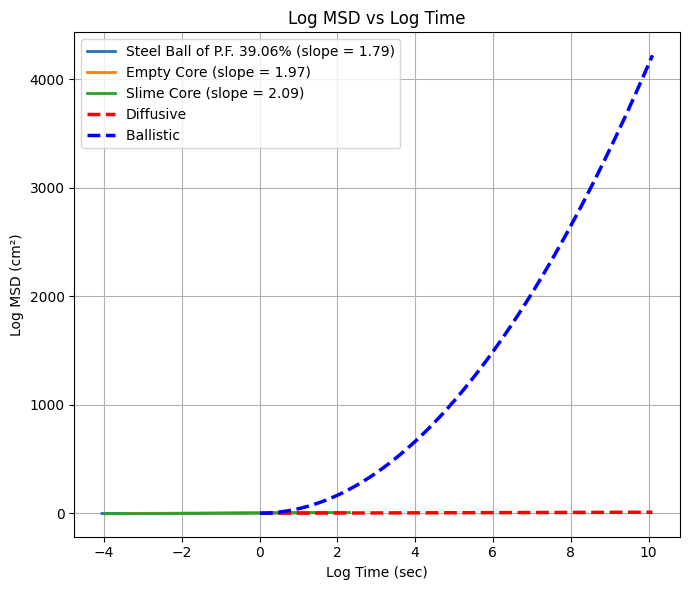

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Conversion constants
x_pixel_to_meter = 0.01899
y_pixel_to_meter = 0.01911
t_frame_to_sec = 0.01667

# List of file paths and corresponding labels
file_paths = [
    '/content/steel_ball_n_200_raw_data.xlsx',
    '/content/empty_core­_raw­_data.xlsx',
    '/content/slime_core.xlsx'
]

labels = [
    'Steel Ball of P.F. 39.06%',
    'Empty Core',
    'Slime Core'
]

# Store average time and MSD for each file
all_avg_time = []
all_avg_msd = []
slopes = []
first_log_points = []

# Process each file
for file_path in file_paths:
    xls = pd.ExcelFile(file_path)

    all_r_squared = []
    all_time_data = []

    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)

        if df.shape[1] >= 8:
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7] * t_frame_to_sec

            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                continue

            r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2
            all_r_squared.append(r_squared.values)
            all_time_data.append(time_data.values)

    if all_r_squared:
        max_length = max(map(len, all_r_squared))

        interpolated_r_squared = [
            np.interp(np.linspace(0, 1, max_length), np.linspace(0, 1, len(r)), r)
            for r in all_r_squared
        ]
        avg_r_squared = np.mean(interpolated_r_squared, axis=0)
        avg_time = np.linspace(0, max([t.max() for t in all_time_data]), max_length)

        all_avg_time.append(avg_time)
        all_avg_msd.append(avg_r_squared)

        # Calculate slope in log-log space
        valid = (avg_time > 0) & (avg_r_squared > 0)
        log_time = np.log(avg_time[valid])
        log_msd = np.log(avg_r_squared[valid])

        finite_mask = np.isfinite(log_time) & np.isfinite(log_msd)
        log_time = log_time[finite_mask]
        log_msd = log_msd[finite_mask]

        if len(log_time) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(log_time, log_msd)
            slopes.append(slope)
            first_log_points.append((log_time[0], log_msd[0]))  # For reference lines
        else:
            slopes.append(np.nan)
            first_log_points.append((np.nan, np.nan))

# Compute average of valid starting log points for reference lines
valid_points = [(x0, y0) for x0, y0 in first_log_points if not np.isnan(x0) and not np.isnan(y0)]
if valid_points:
    x0_avg = np.mean([pt[0] for pt in valid_points])
    y0_avg = np.mean([pt[1] for pt in valid_points])
    t0_avg = np.exp(x0_avg)
    msd0_avg = np.exp(y0_avg)

# Plot MSD vs Time (linear scale)
plt.figure(figsize=(7, 6))
for time, msd, label in zip(all_avg_time, all_avg_msd, labels):
    plt.plot(time, msd, linewidth=2, label=label)

# Add diffusive and ballistic lines to the linear plot
if valid_points:
    time_ref = np.linspace(min([t[0] for t in all_avg_time if len(t) > 0]),
                           max([t[-1] for t in all_avg_time if len(t) > 0]), 100)
    msd_diffusive = msd0_avg * (time_ref / t0_avg)
    msd_ballistic = msd0_avg * (time_ref / t0_avg)**2

    plt.plot(time_ref, msd_diffusive, 'r--', linewidth=2.5, label='Diffusive (slope=1)')
    plt.plot(time_ref, msd_ballistic, 'b--', linewidth=2.5, label='Ballistic (slope=2)')

plt.title('Average Mean Square Displacement vs Time')
plt.xlabel('Time (sec)')
plt.ylabel('MSD (cm²)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Log(MSD) vs Log(Time) with slopes and reference lines
plt.figure(figsize=(7, 6))

# Plot each MSD curve with its slope
for time, msd, label, slope in zip(all_avg_time, all_avg_msd, labels, slopes):
    log_time = np.log(time[time > 0])
    log_msd = np.log(msd[time > 0])
    plt.plot(log_time, log_msd, linewidth=2, label=f'{label} (slope = {slope:.2f})')

# Reference lines from average log-log starting point
# Add diffusive and ballistic lines to the linear plot
if valid_points:
    time_ref = np.linspace(0.01, max([t[-1] for t in all_avg_time if len(t) > 0]), 200)

    # Use ideal slope behavior: A * t^n where A is scaled so log-log slope is exactly 1 or 2
    A_diff = msd0_avg / (t0_avg**1)
    A_ball = msd0_avg / (t0_avg**2)

    msd_diffusive = A_diff * (time_ref**1)
    msd_ballistic = A_ball * (time_ref**2)

    plt.plot(time_ref, msd_diffusive, 'r--', linewidth=2.5, label='Diffusive')
    plt.plot(time_ref, msd_ballistic, 'b--', linewidth=2.5, label='Ballistic ')


plt.title('Log MSD vs Log Time')
plt.xlabel('Log Time (sec)')
plt.ylabel('Log MSD (cm²)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Available sheets: ['Sheet2', 'Sheet5', 'Sheet6', 'Sheet7', 'Sheet8', 'Sheet9', 'Sheet11', 'Sheet12', 'Sheet13', 'Sheet14', 'Sheet15', 'Sheet16', 'Sheet17', 'Sheet18', 'Sheet19', 'Sheet20', 'Sheet21', 'Sheet23', 'Sheet24', 'Sheet25', 'Sheet26', 'Sheet27', 'Sheet28', 'Sheet29', 'Sheet30', 'Sheet32', 'Sheet33', 'Sheet34', 'Sheet35', 'Sheet36', 'Sheet37', 'Sheet39', 'Sheet40', 'Sheet41', 'Sheet42', 'Sheet43', 'Sheet44', 'Sheet45', 'Sheet46', 'Sheet48', 'Sheet50', 'Sheet51', 'Sheet52', 'Sheet53', 'Sheet54', 'Sheet55', 'Sheet56', 'Sheet57', 'Sheet58', 'Sheet59', 'Sheet60', 'Sheet62', 'Sheet63', 'Sheet65', 'Sheet66', 'Sheet67', 'Sheet68', 'Sheet69', 'Sheet70', 'Sheet73', 'Sheet74', 'Sheet75', 'Sheet76', 'Sheet77', 'Sheet78', 'Sheet80', 'Sheet81', 'Sheet84', 'Sheet86', 'Sheet87', 'Sheet89', 'Sheet90', 'Sheet92', 'Sheet93', 'Sheet94', 'Sheet95', 'Sheet96', 'Sheet97', 'Sheet98', 'Sheet99', 'Sheet100', 'Sheet101', 'Sheet102', 'Sheet103', 'Sheet107', 'Sheet108', 'Sheet110', 'Sheet111', 'Sheet112',

<ipython-input-5-94cd1fce1c3d>:57: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


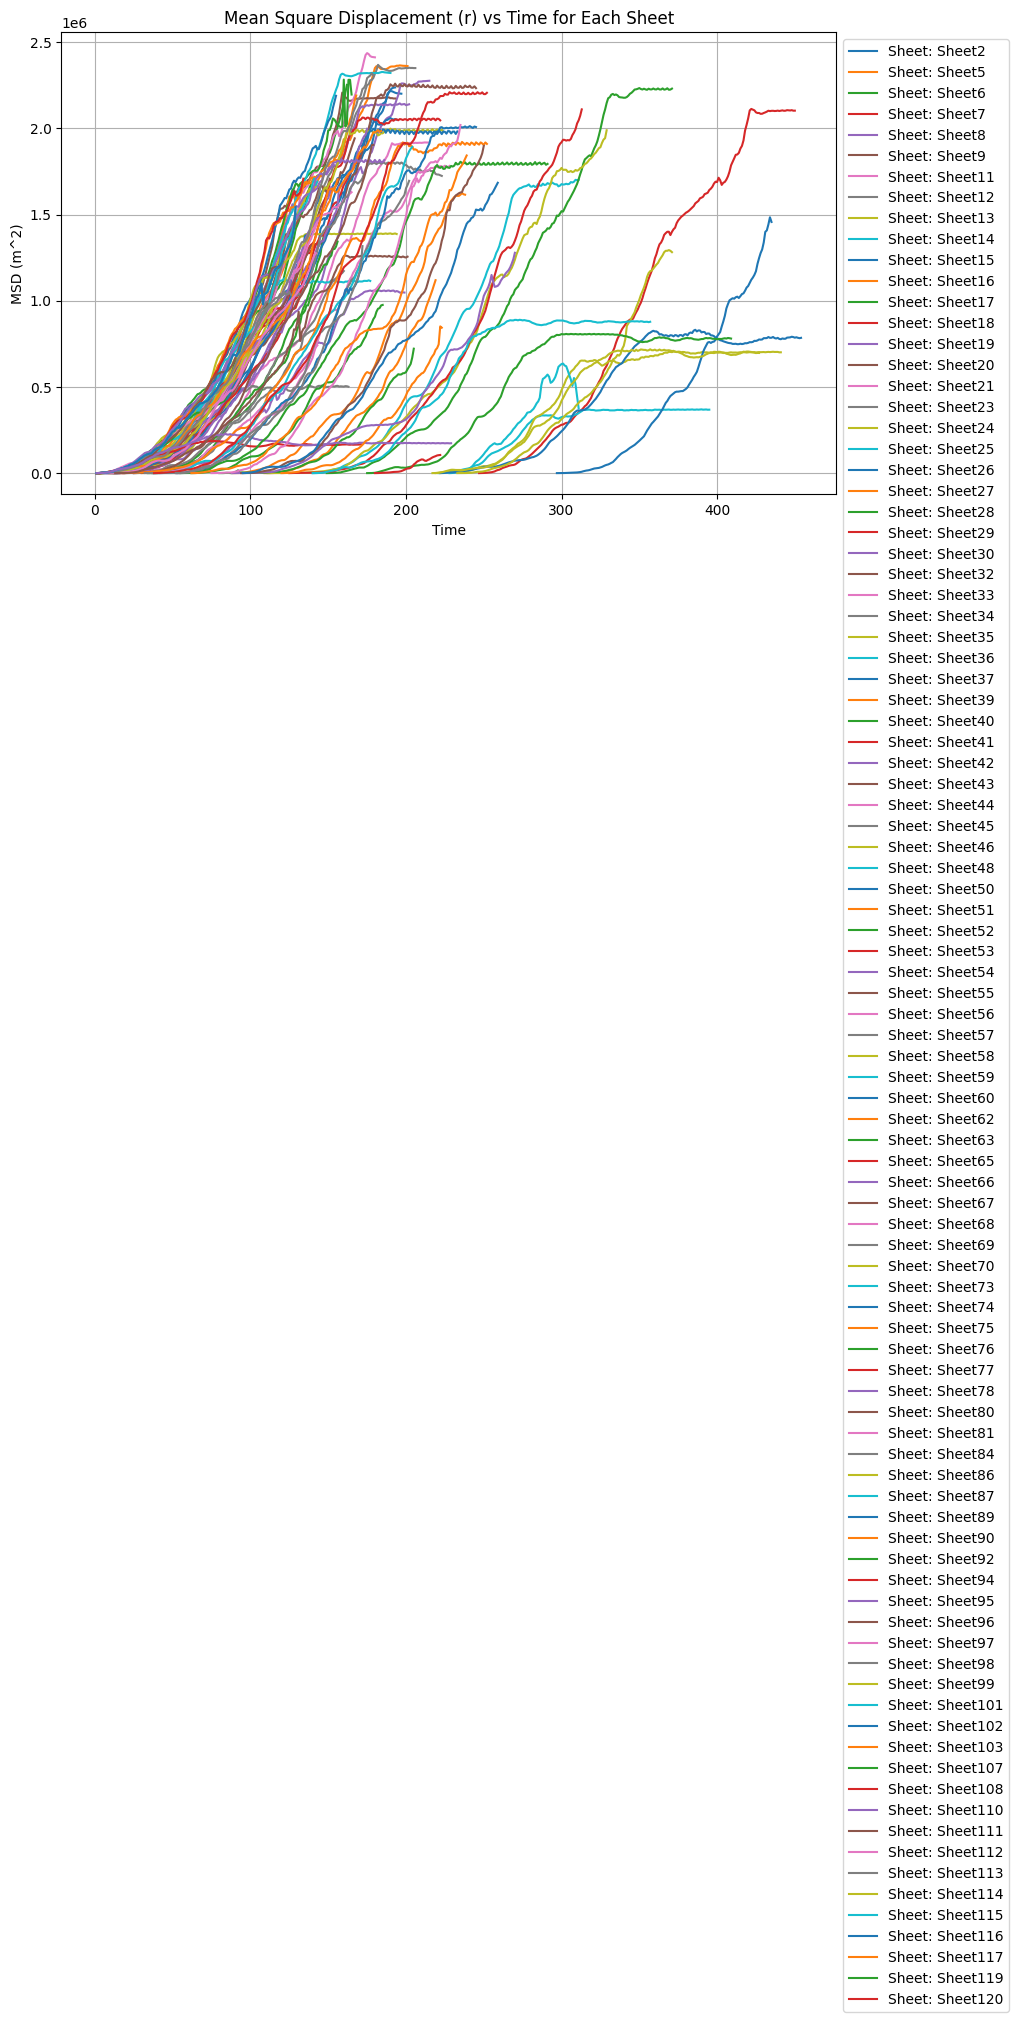

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants for pixel-to-meter conversion
x_pixel_to_meter = 1  # / 1080
y_pixel_to_meter = 1  # / 1920

# Function to read data from Excel sheets and calculate MSD for each sheet
def calculate_and_plot_msd(file_path):
    # Load the Excel file and get sheet names
    xls = pd.ExcelFile(file_path)
    print("Available sheets:", xls.sheet_names)

    plt.figure(figsize=(10, 6))  # Increase figure size for better clarity

    for sheet in xls.sheet_names:
        print(f"Processing sheet: {sheet}")

        # Read data from each sheet
        df = pd.read_excel(file_path, sheet_name=sheet)
        print(df.head())  # Display the first few rows for debugging

        # Ensure required columns exist
        if df.shape[1] >= 8:
            # Extract X, Y, and time columns (X: col 5, Y: col 6, Time: col 8)
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7]

            print(f"x_data length: {len(x_data)}, y_data length: {len(y_data)}, time_data length: {len(time_data)}")

            # Check if data is not empty
            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                print(f"Empty data in sheet: {sheet}")
                continue

            # Calculate displacement 'r' (distance from the initial position)
            r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2

            # Ensure lengths of time and r_squared match
            if len(time_data) == len(r_squared):
                # Plot MSD vs Time for the current sheet
                plt.plot(time_data, r_squared, label=f'Sheet: {sheet}')
            else:
                print(f"Length mismatch in sheet {sheet}: time({len(time_data)}) vs r_squared({len(r_squared)})")

        else:
            print(f"Skipping sheet '{sheet}' as it doesn't contain required columns")

    # Finalize the plot
    plt.title('Mean Square Displacement (r) vs Time for Each Sheet')
    plt.xlabel('Time')
    plt.ylabel('MSD (m^2)')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Move legend outside the plot
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

# File path to the Excel file
file_path = '/content/empty_core­_raw­_data.xlsx'  # Replace with your actual file path

# Run the function
calculate_and_plot_msd(file_path)


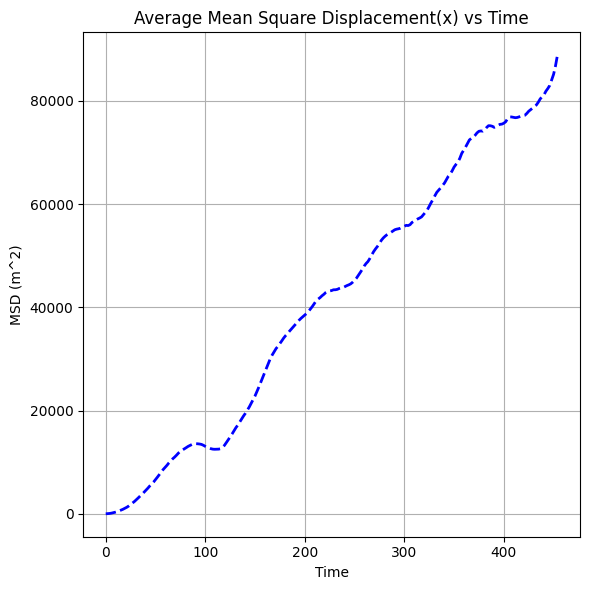

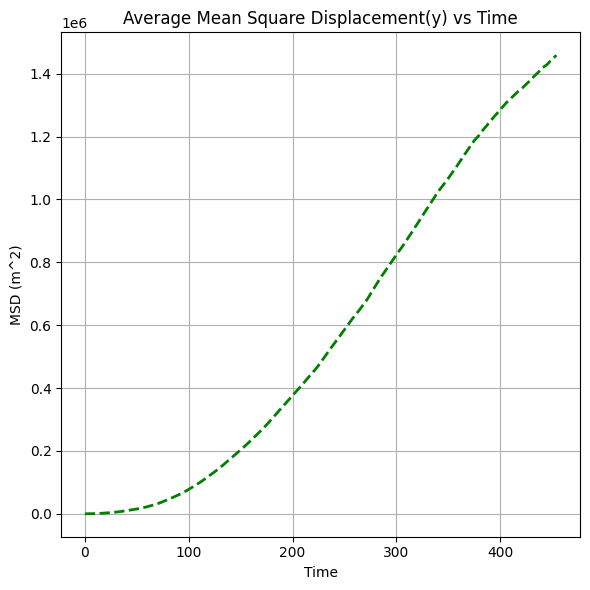

<ipython-input-6-3f031dab0556>:99: RuntimeWarning: divide by zero encountered in log
  logt  = np.log(avg_time)
<ipython-input-6-3f031dab0556>:100: RuntimeWarning: divide by zero encountered in log
  logx2 = np.log(avg_x_squared)
<ipython-input-6-3f031dab0556>:101: RuntimeWarning: divide by zero encountered in log
  logy2 = np.log(avg_y_squared)


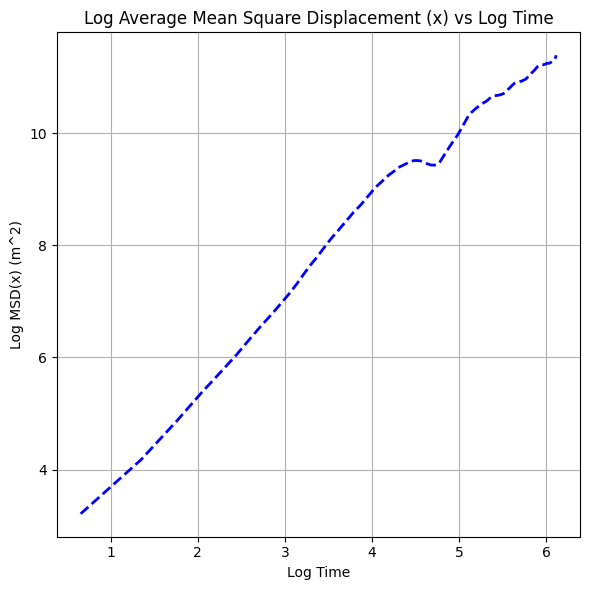

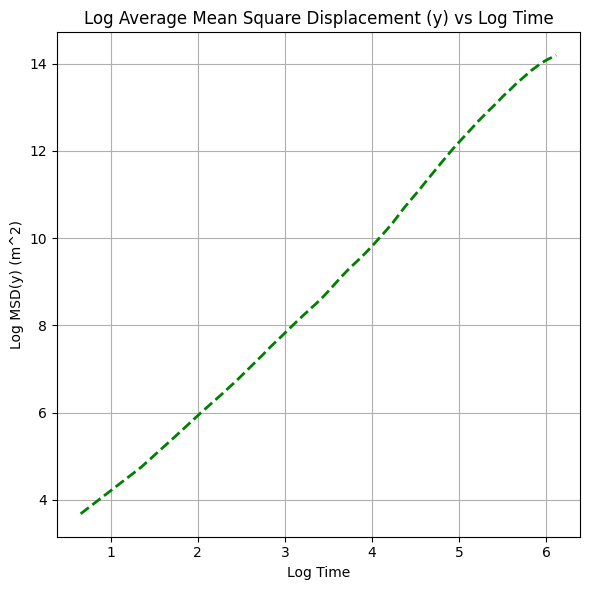

In [ ]:
#FOR ALL TRACKS(NORMALIZED) --> Individual x and y MSD

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants for pixel-to-meter conversion
x_pixel_to_meter = 1  # / 1080
y_pixel_to_meter = 1  # / 1920

# Function to read data from Excel sheets and calculate the average MSD
def calculate_and_plot_average_msd(file_path):
    # Load the Excel file and get sheet names
    xls = pd.ExcelFile(file_path)

    all_x_squared = []
    all_y_squared = []
    all_time_data = []

    for sheet in xls.sheet_names:
        # Read data from each sheet
        df = pd.read_excel(file_path, sheet_name=sheet)

        # Ensure required columns exist
        if df.shape[1] >= 8:
            # Extract X, Y, and time columns (X: col 5, Y: col 6, Time: col 8)
            x_data = df.iloc[:, 4] * x_pixel_to_meter
            y_data = df.iloc[:, 5] * y_pixel_to_meter
            time_data = df.iloc[:, 7]

            # Check if data is not empty
            if len(x_data) == 0 or len(y_data) == 0 or len(time_data) == 0:
                continue

            # Calculate displacement 'x' and 'y' (distance from the initial position)
            #r_squared = (x_data - x_data.iloc[0])**2 + (y_data - y_data.iloc[0])**2
            x_squared = (x_data - x_data.iloc[0])**2
            y_squared = (y_data - y_data.iloc[0])**2

            # Store x_squared, y_squared and time data for averaging later
            #all_r_squared.append(r_squared.values)
            all_x_squared.append(x_squared.values)
            all_y_squared.append(y_squared.values)
            all_time_data.append(time_data.values)

    # Normalize all time and MSD data to the longest length(x)
    if all_x_squared:
        max_length_x = max(map(len, all_x_squared))

        # Interpolate all data to match the maximum length
        interpolated_x_squared = [np.interp(np.linspace(0, 1, max_length_x), np.linspace(0, 1, len(x)), x) for x in all_x_squared]
        avg_x_squared = np.mean(interpolated_x_squared, axis=0)

        # Use the maximum length time axis
        avg_time = np.linspace(0, max([t.max() for t in all_time_data]), max_length_x)

        #Plot the average MSD
        plt.figure(figsize=(6, 6))
        plt.plot(avg_time, avg_x_squared, 'b--', linewidth=2)

        #print(avg_time,' '   ,avg_r_squared, '\n')

        #Finalize the plot
        plt.title('Average Mean Square Displacement(x) vs Time')
        plt.xlabel('Time')
        plt.ylabel('MSD (m^2)')
        plt.grid(True)
        plt.tight_layout()
        plt.show(block=True)


         # Normalize all time and MSD data to the longest length(x)
    if all_y_squared:
        max_length_y = max(map(len, all_y_squared))

         # Interpolate all data to match the maximum length
        interpolated_y_squared = [np.interp(np.linspace(0, 1, max_length_y), np.linspace(0, 1, len(y)), y) for y in all_y_squared]
        avg_y_squared = np.mean(interpolated_y_squared, axis=0)

        # Use the maximum length time axis
        avg_time = np.linspace(0, max([t.max() for t in all_time_data]), max_length_y)

        #Plot the average MSD
        plt.figure(figsize=(6, 6))
        plt.plot(avg_time, avg_y_squared, 'g--', linewidth=2)

        #print(avg_time,' '   ,avg_r_squared, '\n')

        #Finalize the plot
        plt.title('Average Mean Square Displacement(y) vs Time')
        plt.xlabel('Time')
        plt.ylabel('MSD (m^2)')
        plt.grid(True)
        plt.tight_layout()
        plt.show(block=True)


# Plot the average MSD in log scale
    logt  = np.log(avg_time)
    logx2 = np.log(avg_x_squared)
    logy2 = np.log(avg_y_squared)

    plt.figure(figsize=(6, 6))
    plt.plot(logt, logx2, 'b--', linewidth=2, label = 'log scale') #log scale

    plt.title('Log Average Mean Square Displacement (x) vs Log Time')
    plt.xlabel('Log Time')
    plt.ylabel('Log MSD(x) (m^2)')
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)


    plt.figure(figsize=(6, 6))
    plt.plot(logt, logy2, 'g--', linewidth=2, label = 'log scale') #log scale

    plt.title('Log Average Mean Square Displacement (y) vs Log Time')
    plt.xlabel('Log Time')
    plt.ylabel('Log MSD(y) (m^2)')
    plt.grid(True)
    plt.tight_layout()
    plt.show(block=True)

# File path to the Excel file
file_path = '/content/empty_core­_raw­_data.xlsx'  # Replace with your actual file path

# Run the function
calculate_and_plot_average_msd(file_path)


